# Time-Series Momentum Backtest: Static vs Dynamic Trend Following

**Breaking Bad Trends** (Goulding, Harvey & Mazzoleni, 2023 FAJ) replication

- Assets: 43 futures (11 equity, 8 bond, 24 commodity) → yfinance proxy
- Signals: Slow=12M, Fast=2M
- Static: sign(slow) × r
- Dynamic: fast/slow blending at turning points (Correction/Rebound), mixing params via expanding window

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from tsmom import (
    momentum_signals, classify_states,
    static_trend_returns, fast_trend_returns,
    estimate_mixing_params, dynamic_trend_returns,
    equal_weight_portfolio, ex_post_vol_scale, vol_target_portfolio,
    annualized_stats, max_drawdown, state_decomposition,
    run_backtest, print_summary,
)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.family"] = "DejaVu Sans"

## 1. Data

Paper uses 43 Barchart futures. Here we use yfinance proxies:
- **Equity index futures**: Major country ETFs
- **Bond futures**: Treasury ETF proxies
- **Commodity futures**: Commodity ETF proxies

In [5]:
# Asset universe (yfinance proxies)
EQUITY_TICKERS = {
    "SPY": "US Equity",
    "EWJ": "Japan Equity",
    "EWU": "UK Equity",
    "EWG": "Germany Equity",
    "EWA": "Australia Equity",
    "EWC": "Canada Equity",
    "EWH": "HK Equity",
    "EWQ": "France Equity",
    "EWI": "Italy Equity",
    "EWN": "Netherlands Equity",
    "EWD": "Sweden Equity",
}

BOND_TICKERS = {
    "IEF": "US 10Y Bond",
    "TLT": "US 20Y+ Bond",
    "BWX": "Intl Bond",
}

COMMODITY_TICKERS = {
    "GLD": "Gold",
    "SLV": "Silver",
    "USO": "WTI Crude",
    "UNG": "Natural Gas",
    "DBA": "Agriculture",
    "DBB": "Base Metals",
    "CPER": "Copper",
}

ALL_TICKERS = {**EQUITY_TICKERS, **BOND_TICKERS, **COMMODITY_TICKERS}
print(f"Total {len(ALL_TICKERS)} assets")

Total 21 assets


In [6]:
# Download prices & compute monthly returns
tickers = list(ALL_TICKERS.keys())
prices = yf.download(tickers, start="1998-01-01", end="2024-12-31", auto_adjust=True)["Close"]
prices = prices.dropna(axis=1, how="all")

monthly_prices = prices.resample("ME").last()
returns = monthly_prices.pct_change().dropna(how="all")

print(f"Period: {returns.index[0].strftime('%Y-%m')} ~ {returns.index[-1].strftime('%Y-%m')}")
print(f"Assets: {returns.shape[1]}")
print(f"Months: {returns.shape[0]}")
returns.head(3)

[*********************100%***********************]  21 of 21 completed


Period: 1998-02 ~ 2024-12
Assets: 21
Months: 323


Ticker,BWX,CPER,DBA,DBB,EWA,EWC,EWD,EWG,EWH,EWI,...,EWN,EWQ,EWU,GLD,IEF,SLV,SPY,TLT,UNG,USO
Date,,,,,,,,,,,,,,,,,,,,,
1998-02-28,NaN,NaN,NaN,NaN,-0.006211,0.094787,0.090909,0.065973,0.099379,0.040463,...,0.098361,0.100775,0.067114,NaN,NaN,NaN,0.069295,NaN,NaN,NaN
1998-03-31,NaN,NaN,NaN,NaN,0.031250,0.056277,0.074074,0.068403,0.000000,0.194444,...,0.047264,0.102113,0.078617,NaN,NaN,NaN,0.048784,NaN,NaN,NaN
1998-04-30,NaN,NaN,NaN,NaN,-0.006061,0.000000,0.068966,0.064025,-0.096045,-0.018605,...,0.033254,0.035144,-0.008747,NaN,NaN,NaN,0.012791,NaN,NaN,NaN


## 2. Backtest (Full Sample)

In [7]:
result = run_backtest(returns, k_slow=12, k_fast=2, target_vol=0.10, tcost_bps=0.0)
print_summary(result)

Time-Series Momentum Backtest Results

                           Static      Dynamic
--------------------------------------------
Ann. Return                3.09%       4.30%
Ann. Vol                  10.00%      10.00%
Sharpe                     0.309       0.430
Max Drawdown             -34.95%     -22.74%

Return Decomposition by State (Static)
                count  ann_return  total_contrib
Bull            165.0    0.078816       1.083717
Correction       40.0    0.023024       0.076747
Bear             72.0   -0.002853      -0.017117
Rebound          33.0   -0.080732      -0.222014
Turning Points   73.0   -0.023879      -0.145267

Return Decomposition by State (Dynamic)
                count  ann_return  total_contrib
Bull            165.0    0.074617       1.025989
Correction       40.0    0.006835       0.022784
Bear             72.0   -0.008910      -0.053457
Rebound          33.0    0.058915       0.162017
Turning Points   73.0    0.030378       0.184801


## 3. Cumulative Returns (Figure E.1)

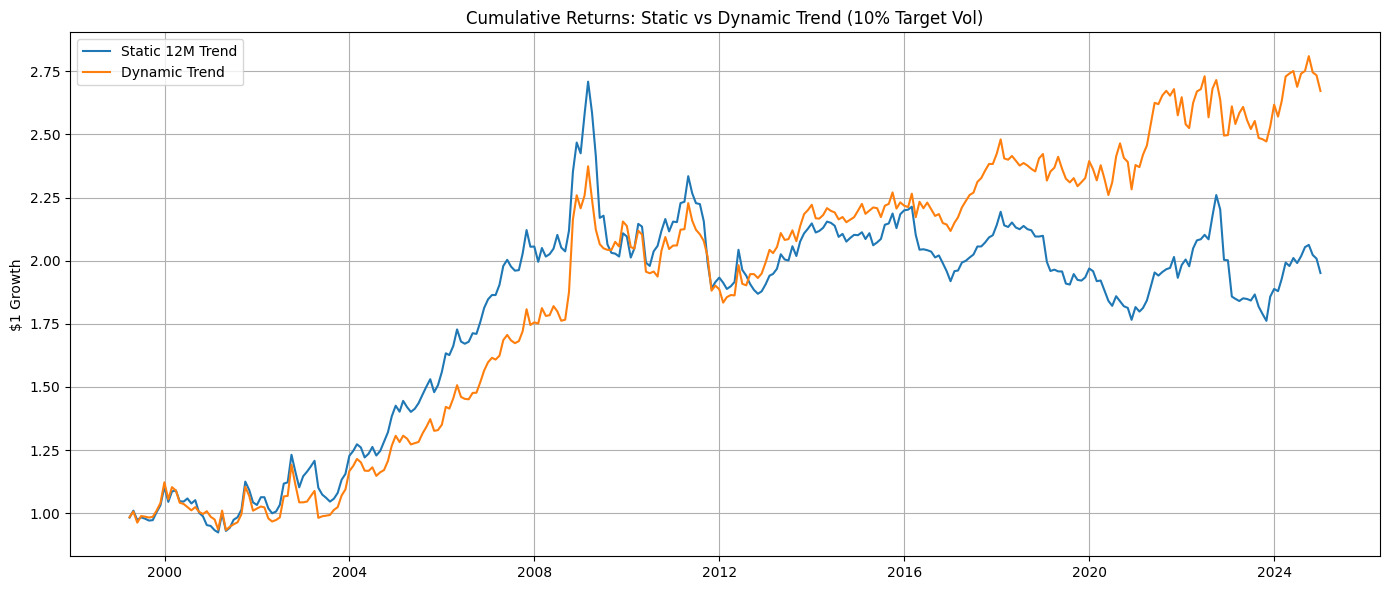

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

cum_static = (1 + result["port_static"]).cumprod()
cum_dynamic = (1 + result["port_dynamic"]).cumprod()

ax.plot(cum_static.index, cum_static.values, label="Static 12M Trend", linewidth=1.5)
ax.plot(cum_dynamic.index, cum_dynamic.values, label="Dynamic Trend", linewidth=1.5)
ax.set_ylabel("$1 Growth")
ax.set_title("Cumulative Returns: Static vs Dynamic Trend (10% Target Vol)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Return Decomposition by State (Figure 4)

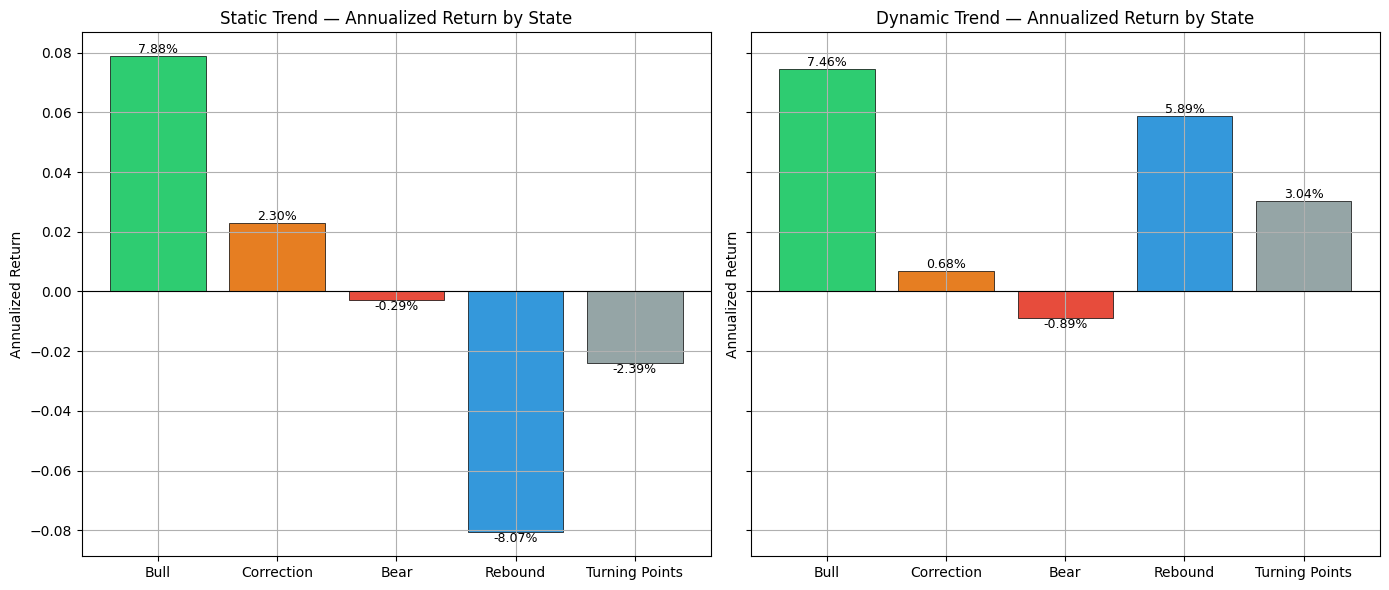

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (label, decomp) in zip(axes, [("Static", result["decomp_static"]),
                                        ("Dynamic", result["decomp_dynamic"])]):
    states_order = ["Bull", "Correction", "Bear", "Rebound", "Turning Points"]
    colors = ["#2ecc71", "#e67e22", "#e74c3c", "#3498db", "#95a5a6"]
    vals = [decomp.loc[s, "ann_return"] if s in decomp.index else 0 for s in states_order]

    bars = ax.bar(states_order, vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{label} Trend — Annualized Return by State")
    ax.set_ylabel("Annualized Return")
    ax.axhline(0, color="black", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.2%}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Asset-level state decomposition (per-asset state labels, no cross-asset mode aggregation)
# Edit SELECTED_TICKERS to inspect specific assets
SELECTED_TICKERS_DECOMP = ["SPY", "TLT", "GLD", "USO", "EWJ"]

for tk in SELECTED_TICKERS_DECOMP:
    if tk not in result["decomp_dynamic_asset"]:
        print(f"[warn] {tk} not found")
        continue
    print(f"=== {tk} ===")
    static_df = result["decomp_static_asset"][tk][["count", "ann_return", "total_contrib"]]
    dyn_df = result["decomp_dynamic_asset"][tk][["count", "ann_return", "total_contrib"]]
    combined = pd.concat(
        [static_df.add_prefix("S_"), dyn_df.add_prefix("D_")], axis=1
    )
    print(combined.to_string())
    print()

# Visual: bar chart of per-asset dynamic ann_return by state for selected tickers
fig, ax = plt.subplots(figsize=(12, 5))
states_order = ["Bull", "Correction", "Bear", "Rebound"]
x = np.arange(len(SELECTED_TICKERS_DECOMP))
width = 0.2
for j, s in enumerate(states_order):
    vals = [result["decomp_dynamic_asset"][tk].loc[s, "ann_return"]
            if tk in result["decomp_dynamic_asset"] else 0 for tk in SELECTED_TICKERS_DECOMP]
    ax.bar(x + (j - 1.5) * width, vals, width, label=s)
ax.set_xticks(x)
ax.set_xticklabels(SELECTED_TICKERS_DECOMP)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Annualized Return")
ax.set_title("Per-Asset Dynamic Trend Return by State")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 5. Turning Point Frequency vs Performance (Figure 2)

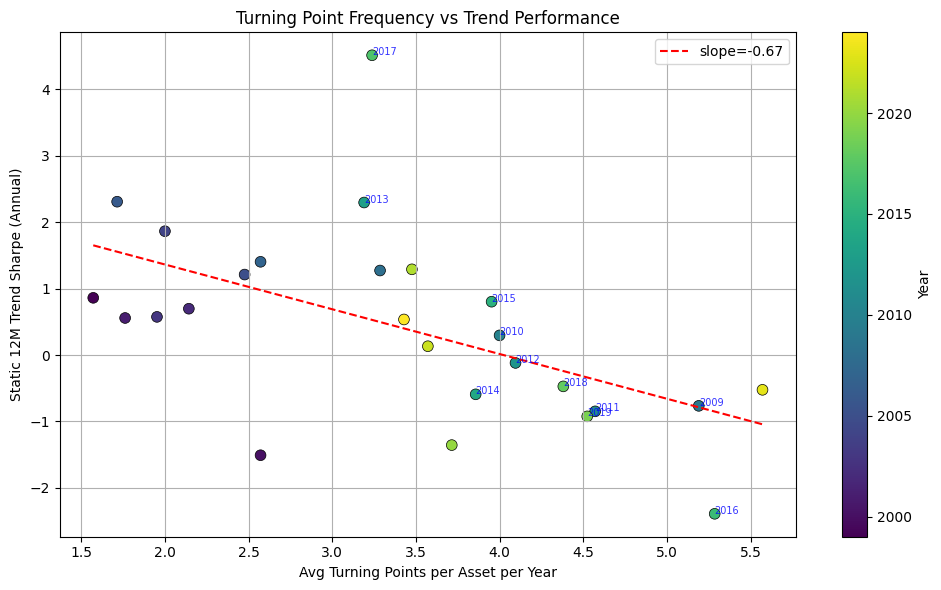

Correlation: -0.539, R²: 0.290


In [10]:
# Yearly turning point count vs static trend Sharpe
x_slow, x_fast = momentum_signals(returns, k_slow=12, k_fast=2)
states = classify_states(x_slow, x_fast)
r_static = static_trend_returns(returns, x_slow)

# Yearly aggregation
years = returns.index.year.unique()
yearly_data = []

for yr in years:
    mask = returns.index.year == yr
    if mask.sum() < 6:
        continue

    # Turning points per year: asset average
    st_yr = states.loc[mask]
    tp_counts = ((st_yr == "Correction") | (st_yr == "Rebound")).sum(axis=0)  # per-asset
    avg_tp = tp_counts.mean()

    # Static trend portfolio annual Sharpe
    r_yr = r_static.loc[mask].mean(axis=1)  # equal-weight
    if r_yr.std() > 0:
        sharpe_yr = r_yr.mean() / r_yr.std() * np.sqrt(12)
    else:
        sharpe_yr = np.nan

    yearly_data.append({"year": yr, "avg_turning_points": avg_tp, "sharpe": sharpe_yr})

ydf = pd.DataFrame(yearly_data).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(ydf["avg_turning_points"], ydf["sharpe"], c=ydf["year"], cmap="viridis", s=60, edgecolors="black", linewidth=0.5)

# Regression line
z = np.polyfit(ydf["avg_turning_points"], ydf["sharpe"], 1)
p = np.poly1d(z)
x_line = np.linspace(ydf["avg_turning_points"].min(), ydf["avg_turning_points"].max(), 50)
ax.plot(x_line, p(x_line), "r--", linewidth=1.5, label=f"slope={z[0]:.2f}")

# Year labels (post-GFC highlighted)
for _, row in ydf.iterrows():
    if 2009 <= row["year"] <= 2019:
        ax.annotate(int(row["year"]), (row["avg_turning_points"], row["sharpe"]),
                    fontsize=7, color="blue", alpha=0.8)

ax.set_xlabel("Avg Turning Points per Asset per Year")
ax.set_ylabel("Static 12M Trend Sharpe (Annual)")
ax.set_title("Turning Point Frequency vs Trend Performance")
ax.legend()
plt.colorbar(sc, label="Year")
plt.tight_layout()
plt.show()

# Report R²
from numpy.polynomial.polynomial import polyfit as np_polyfit
corr = ydf["avg_turning_points"].corr(ydf["sharpe"])
print(f"Correlation: {corr:.3f}, R²: {corr**2:.3f}")

## 6. Sub-Period Comparison (Table E.1)

In [11]:
# Sub-period statistics
subperiods = {
    "Full Sample": (None, None),
    "Through GFC (~ 2008)": (None, "2008-12-31"),
    "Post GFC (2009 ~)": ("2009-01-01", None),
    "Post GFC Expansion (2009-2019)": ("2009-01-01", "2019-12-31"),
    "Post COVID (2020 ~)": ("2020-01-01", None),
}

rows = []
for label, (start, end) in subperiods.items():
    ps = result["port_static"]
    pd_ = result["port_dynamic"]

    if start:
        ps = ps[ps.index >= start]
        pd_ = pd_[pd_.index >= start]
    if end:
        ps = ps[ps.index <= end]
        pd_ = pd_[pd_.index <= end]

    if len(ps) < 12:
        continue

    ss = annualized_stats(ps)
    sd = annualized_stats(pd_)

    rows.append({
        "Period": label,
        "Static Return": f"{ss['ann_return']:.2%}",
        "Static Vol": f"{ss['ann_vol']:.2%}",
        "Static Sharpe": f"{ss['sharpe']:.3f}",
        "Dynamic Return": f"{sd['ann_return']:.2%}",
        "Dynamic Vol": f"{sd['ann_vol']:.2%}",
        "Dynamic Sharpe": f"{sd['sharpe']:.3f}",
    })

table = pd.DataFrame(rows).set_index("Period")
table

,Static Return,Static Vol,Static Sharpe,Dynamic Return,Dynamic Vol,Dynamic Sharpe
Period,,,,,,
Full Sample,3.09%,10.00%,0.309,4.30%,10.00%,0.430
Through GFC (~ 2008),9.71%,11.69%,0.831,8.84%,12.51%,0.706
Post GFC (2009 ~),-0.98%,8.62%,-0.114,1.51%,8.01%,0.189
Post GFC Expansion (2009-2019),-1.52%,8.64%,-0.175,1.02%,7.57%,0.135
Post COVID (2020 ~),0.19%,8.64%,0.022,2.59%,8.97%,0.289


## 7. Mixing Parameters (aCo, aRe) Time Series

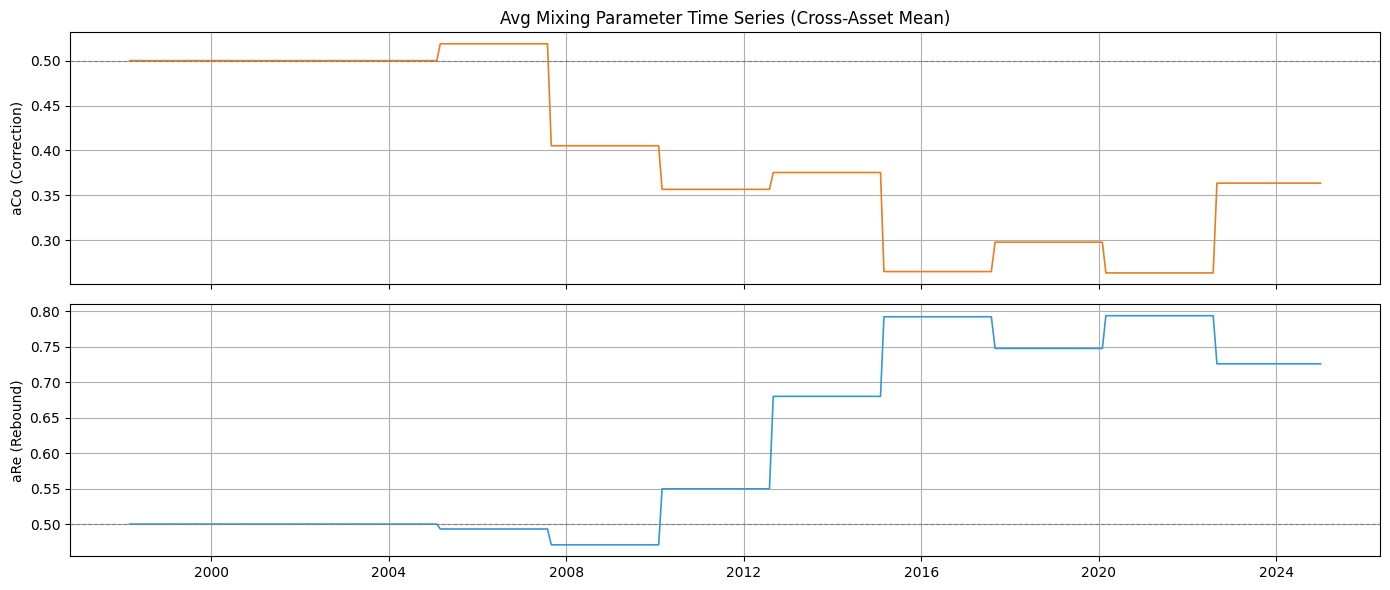

aCo mean: 0.393 (< 0.5 → favors slow, mean-reversion)
aRe mean: 0.616 (> 0.5 → favors fast, trend reversal)


In [13]:
# Cross-asset average aCo, aRe time series
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

avg_aco = result["a_co"].mean(axis=1).dropna()
avg_are = result["a_re"].mean(axis=1).dropna()

axes[0].plot(avg_aco.index, avg_aco.values, color="#e67e22", linewidth=1.2)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("aCo (Correction)")
axes[0].set_title("Avg Mixing Parameter Time Series (Cross-Asset Mean)")

axes[1].plot(avg_are.index, avg_are.values, color="#3498db", linewidth=1.2)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("aRe (Rebound)")

plt.tight_layout()
plt.show()

print(f"aCo mean: {avg_aco.mean():.3f} (< 0.5 → favors slow, mean-reversion)")
print(f"aRe mean: {avg_are.mean():.3f} (> 0.5 → favors fast, trend reversal)")

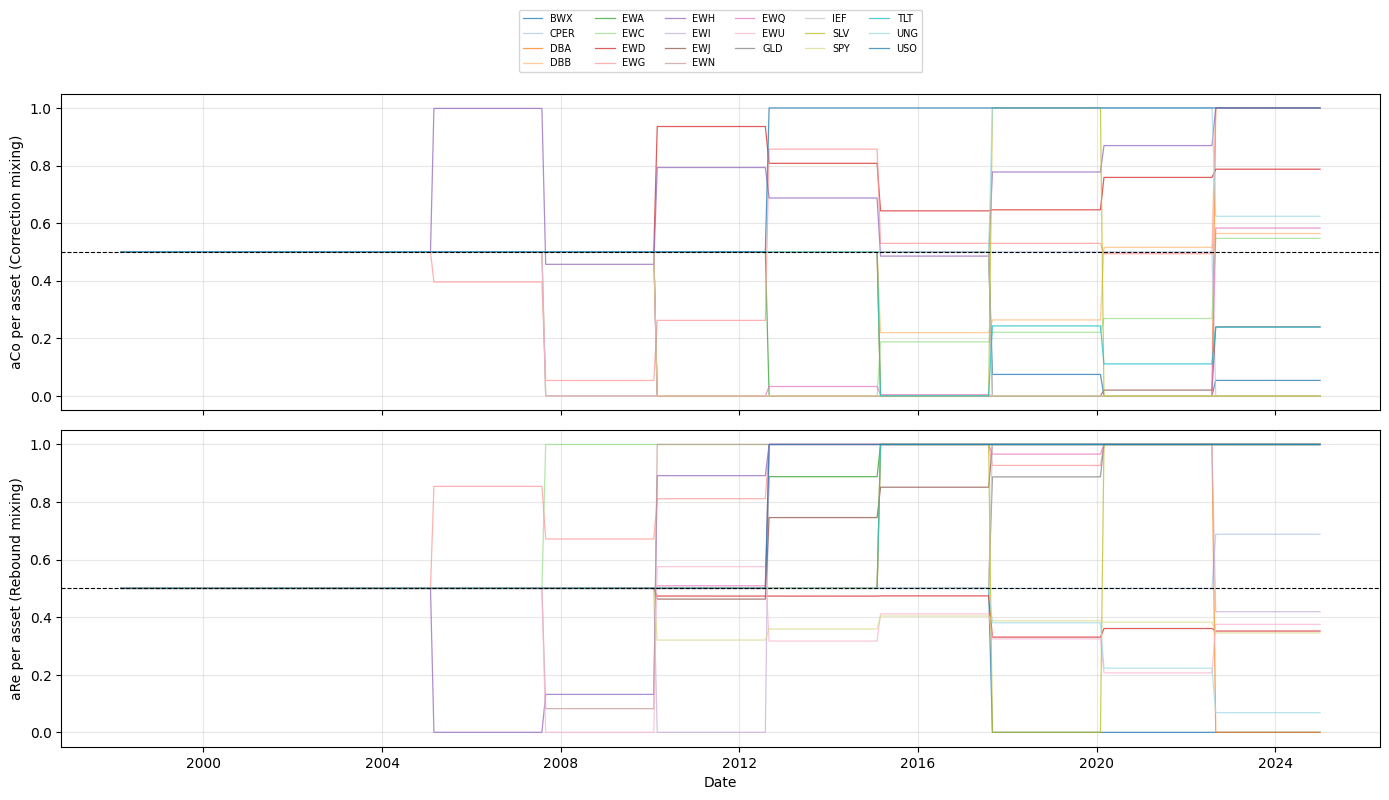

Latest mixing parameters per asset:
            a_co      a_re Co_tilt Re_tilt
Ticker                                    
CPER    0.000000  0.687964    slow    fast
EWA     0.000000  1.000000    slow    fast
EWN     0.000000  1.000000    slow    fast
IEF     0.000000  1.000000    slow    fast
EWU     0.000000  0.375090    slow    slow
GLD     0.000000  1.000000    slow    fast
EWI     0.000000  0.419077    slow    slow
SLV     0.000000  1.000000    slow    fast
SPY     0.000000  0.345338    slow    slow
BWX     0.053529  0.000000    slow    slow
TLT     0.238294  1.000000    slow    fast
EWJ     0.239499  1.000000    slow    fast
EWC     0.546908  1.000000    fast    fast
DBB     0.563880  1.000000    fast    fast
EWQ     0.582700  1.000000    fast    fast
UNG     0.623631  0.068325    fast    slow
EWD     0.787158  0.351865    fast    slow
EWH     1.000000  1.000000    fast    fast
DBA     1.000000  0.000000    fast    slow
EWG     1.000000  1.000000    fast    fast
USO     1.000000  

In [14]:
# Per-asset aCo / aRe history (user-selected tickers)
# Edit this list to control which assets appear in the chart
SELECTED_TICKERS = ["SPY", "TLT", "GLD", "USO", "EWJ"]

a_co_df = result["a_co"].dropna(how="all")
a_re_df = result["a_re"].dropna(how="all")

tickers = [t for t in SELECTED_TICKERS if t in a_co_df.columns]
missing = [t for t in SELECTED_TICKERS if t not in a_co_df.columns]
if missing:
    print(f"[warn] tickers not in result: {missing}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
cmap = plt.cm.tab10
colors = [cmap(i % 10) for i in range(len(tickers))]

for i, col in enumerate(tickers):
    axes[0].plot(a_co_df.index, a_co_df[col], color=colors[i], linewidth=1.3, label=col)
    axes[1].plot(a_re_df.index, a_re_df[col], color=colors[i], linewidth=1.3, label=col)

for ax, title in zip(axes, ["aCo (Correction mixing)", "aRe (Rebound mixing)"]):
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)

axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Latest snapshot for selected tickers
latest_aco = a_co_df[tickers].iloc[-1].rename("a_co")
latest_are = a_re_df[tickers].iloc[-1].rename("a_re")
snapshot = pd.concat([latest_aco, latest_are], axis=1).sort_values("a_co")
snapshot["Co_tilt"] = snapshot["a_co"].apply(lambda x: "slow" if x < 0.5 else ("fast" if x > 0.5 else "neutral"))
snapshot["Re_tilt"] = snapshot["a_re"].apply(lambda x: "slow" if x < 0.5 else ("fast" if x > 0.5 else "neutral"))
print("Latest mixing parameters (selected tickers):")
print(snapshot.to_string())

## 8. State Frequency Heatmap

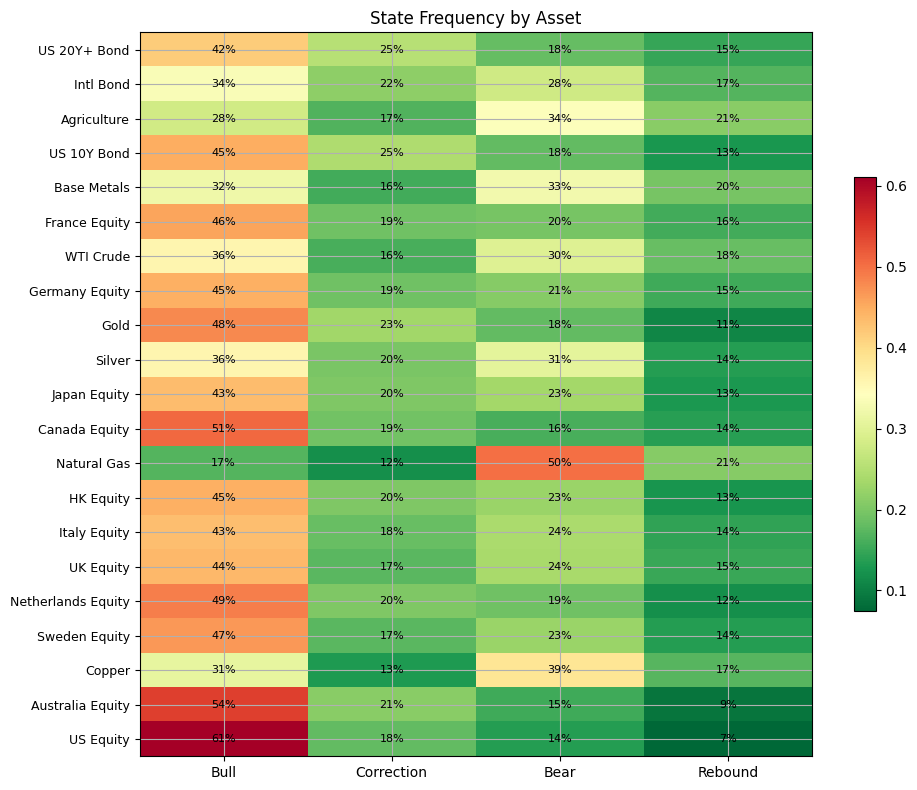


TP share avg: 33.7%
TP share max: 40.1% (US 20Y+ Bond)
TP share min: 25.4% (US Equity)


In [10]:
# State frequency by asset
state_freq = pd.DataFrame(index=returns.columns)
for s in ["Bull", "Correction", "Bear", "Rebound"]:
    state_freq[s] = (states == s).sum() / states.notna().sum()

# Turning point share
state_freq["Turning Points"] = state_freq["Correction"] + state_freq["Rebound"]
state_freq = state_freq.sort_values("Turning Points", ascending=False)

# Map to asset names
state_freq.index = [ALL_TICKERS.get(t, t) for t in state_freq.index]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(state_freq[["Bull", "Correction", "Bear", "Rebound"]].values,
               aspect="auto", cmap="RdYlGn_r")
ax.set_yticks(range(len(state_freq)))
ax.set_yticklabels(state_freq.index, fontsize=9)
ax.set_xticks(range(4))
ax.set_xticklabels(["Bull", "Correction", "Bear", "Rebound"])
ax.set_title("State Frequency by Asset")

# Show values
for i in range(len(state_freq)):
    for j in range(4):
        ax.text(j, i, f"{state_freq.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8)

plt.colorbar(im, shrink=0.6)
plt.tight_layout()
plt.show()

print(f"\nTP share avg: {state_freq['Turning Points'].mean():.1%}")
print(f"TP share max: {state_freq['Turning Points'].max():.1%} ({state_freq['Turning Points'].idxmax()})")
print(f"TP share min: {state_freq['Turning Points'].min():.1%} ({state_freq['Turning Points'].idxmin()})")

## 9. Vol Scaling Comparison (Raw / Ex-post / Realtime)

In [11]:
# Reload tsmom then compare 3 modes
from importlib import reload
import tsmom; reload(tsmom)
from tsmom import run_backtest, print_summary

result_raw = run_backtest(returns, k_slow=12, k_fast=2, target_vol=None, tcost_bps=0.0)
result_expost = run_backtest(returns, k_slow=12, k_fast=2, target_vol=0.10, vol_mode="ex_post", tcost_bps=0.0)
result_rt = run_backtest(returns, k_slow=12, k_fast=2, target_vol=0.10, vol_mode="realtime", tcost_bps=0.0)

print("=== Raw (Table E.1 style) ===")
print_summary(result_raw)

print("\n=== Ex-post 10% vol (paper figures, not tradeable) ===")
print_summary(result_expost)

print("\n=== Realtime vol target 10% (tradeable) ===")
print_summary(result_rt)

=== Raw (Table E.1 style) ===
Time-Series Momentum Backtest Results

                           Static      Dynamic
--------------------------------------------
Ann. Return                3.57%       4.48%
Ann. Vol                  11.55%      10.41%
Sharpe                     0.309       0.430
Max Drawdown             -39.74%     -23.61%

Return Decomposition by State (Static)
                count  ann_return  total_contrib
Bull            165.0    0.078816       1.083716
Correction       40.0    0.023024       0.076747
Bear             72.0   -0.002853      -0.017117
Rebound          33.0   -0.080732      -0.222013
Turning Points   73.0   -0.023879      -0.145266

Return Decomposition by State (Dynamic)
                count  ann_return  total_contrib
Bull            165.0    0.074617       1.025989
Correction       40.0    0.006835       0.022784
Bear             72.0   -0.008910      -0.053457
Rebound          33.0    0.058915       0.162018
Turning Points   73.0    0.030378      

## 10. Fast Lookback Sensitivity (1M vs 2M vs 3M)

In [12]:
# Fast lookback sensitivity analysis
sensitivity_rows = []
for kf in [1, 2, 3]:
    res = run_backtest(returns, k_slow=12, k_fast=kf, target_vol=0.10, tcost_bps=0.0)
    s = res["stats"]
    sensitivity_rows.append({
        "k_fast": kf,
        "Static Sharpe": f"{s['static']['sharpe']:.3f}",
        "Dynamic Sharpe": f"{s['dynamic']['sharpe']:.3f}",
        "Static Return": f"{s['static']['ann_return']:.2%}",
        "Dynamic Return": f"{s['dynamic']['ann_return']:.2%}",
        "Dynamic MDD": f"{s['dynamic_mdd']:.2%}",
    })

sens_df = pd.DataFrame(sensitivity_rows).set_index("k_fast")
sens_df

,Static Sharpe,Dynamic Sharpe,Static Return,Dynamic Return,Dynamic MDD
k_fast,,,,,
1,0.309,0.337,3.09%,3.37%,-25.08%
2,0.309,0.430,3.09%,4.30%,-22.74%
3,0.309,0.368,3.09%,3.68%,-20.67%


## 11. Asset Positions & Portfolio Weights

Each asset position is in [-1, +1]:
- **Static**: always +1 (long) or -1 (short)
- **Dynamic**: same as static in Bull/Bear; blended intermediate values in Correction/Rebound

**Pre-scale weight** = (1/N) × position (raw directional, gross ≤ 100%)

**Post-scale weight** = pre-scale × vol-targeting factor. Two axes:
- **Level**: `portfolio` (single factor on 1/N port, paper method) or `asset` (per-asset factor → risk-parity style)
- **Mode**: `ex_post` (full-sample scalar) or `realtime` (rolling 36M, clip 3×, `shift(1)`, tradeable)

In [13]:
# Recalculate positions (reflects tsmom.py updates)
from importlib import reload
import tsmom; reload(tsmom)
from tsmom import run_backtest, print_summary, dynamic_trend_positions

result = run_backtest(returns, k_slow=12, k_fast=2, target_vol=0.10, tcost_bps=0.0)

pos_s = result["pos_static"]   # Static position: +1 or -1
pos_d = result["pos_dynamic"]  # Dynamic position: [-1, +1]
n_assets = pos_s.shape[1]

# Portfolio weight = (1/N) × position
wt_static = pos_s / n_assets
wt_dynamic = pos_d / n_assets

# --- Latest month position snapshot ---
latest = pos_d.dropna(how="all").index[-1]
snap = pd.DataFrame({
    "Static Pos": pos_s.loc[latest],
    "Dynamic Pos": pos_d.loc[latest].round(3),
    "State": result["states"].loc[latest],
    "Static Wt": wt_static.loc[latest].round(4),
    "Dynamic Wt": wt_dynamic.loc[latest].round(4),
})
snap.index = [ALL_TICKERS.get(t, t) for t in snap.index]
print(f"Latest position snapshot: {latest.strftime('%Y-%m')}\n")
snap

Latest position snapshot: 2024-12



,Static Pos,Dynamic Pos,State,Static Wt,Dynamic Wt
Intl Bond,1.0,0.893,Correction,0.0476,0.0425
Copper,1.0,1.000,Correction,0.0476,0.0476
Agriculture,1.0,1.000,Bull,0.0476,0.0476
Base Metals,1.0,-0.128,Correction,0.0476,-0.0061
Australia Equity,1.0,1.000,Correction,0.0476,0.0476
Canada Equity,1.0,1.000,Bull,0.0476,0.0476
Sweden Equity,1.0,-0.574,Correction,0.0476,-0.0273
Germany Equity,1.0,-1.000,Correction,0.0476,-0.0476
HK Equity,1.0,-1.000,Correction,0.0476,-0.0476
Italy Equity,1.0,1.000,Correction,0.0476,0.0476


/tmp/ipykernel_348771/1892930722.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


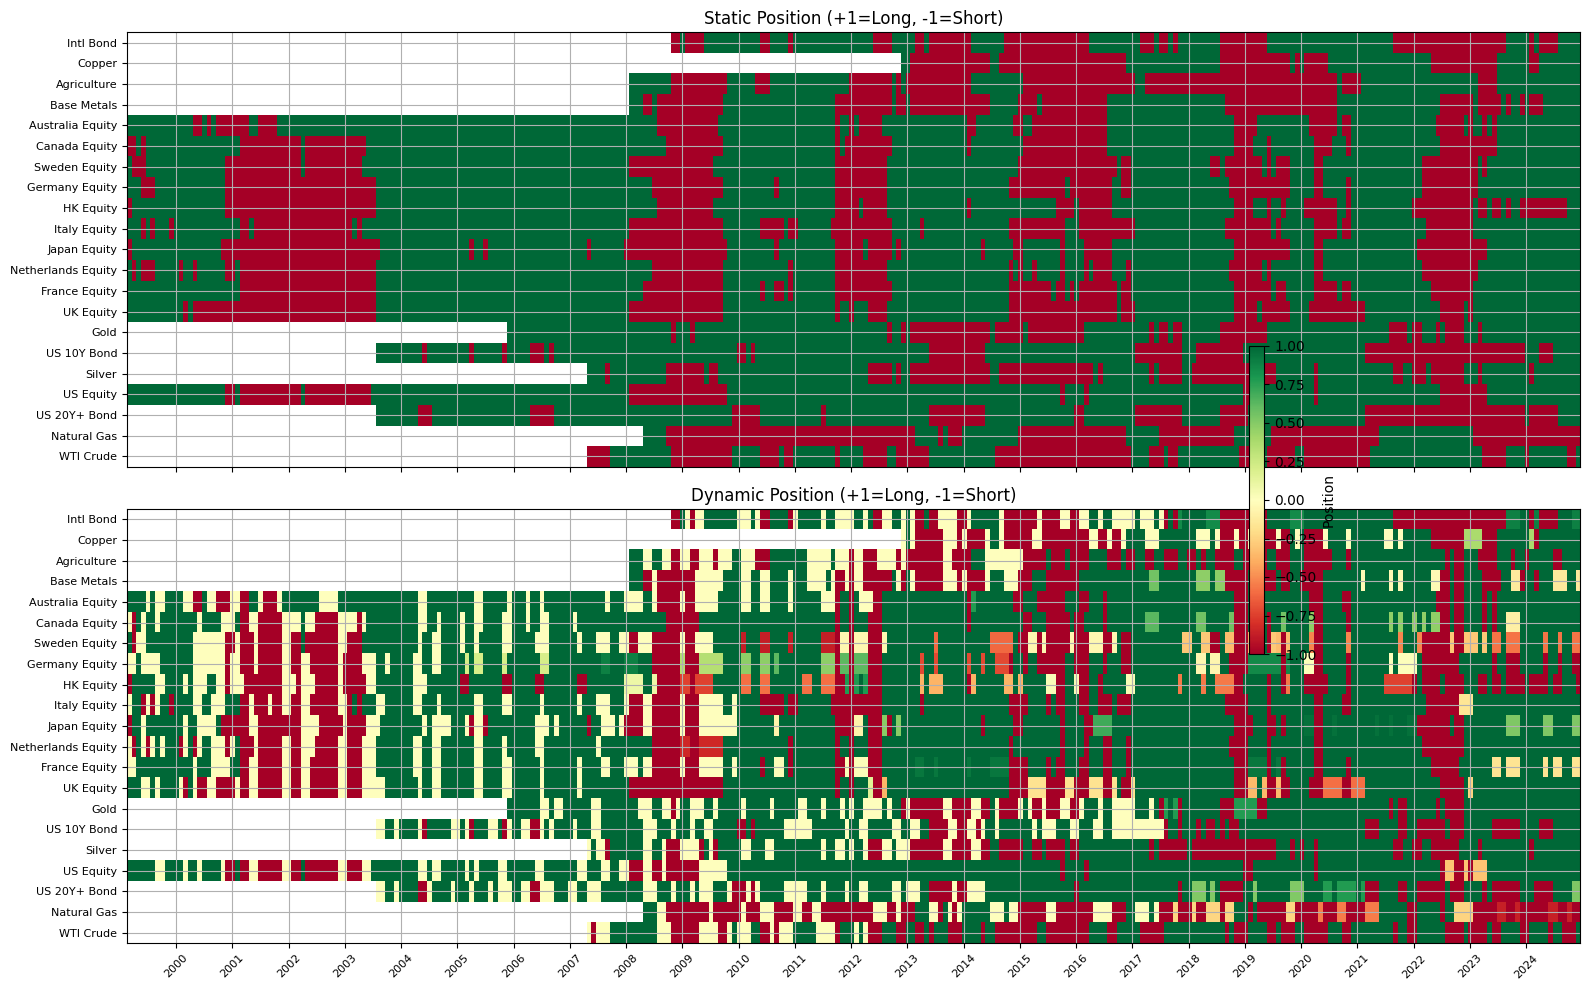

In [14]:
# --- Dynamic position heatmap (time × asset) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Evaluation period only
eval_pos_s = pos_s.iloc[13:].dropna(how="all")
eval_pos_d = pos_d.iloc[13:].dropna(how="all")
col_labels = [ALL_TICKERS.get(t, t) for t in eval_pos_s.columns]

for ax, (title, pos) in zip(axes, [("Static", eval_pos_s), ("Dynamic", eval_pos_d)]):
    im = ax.imshow(pos.T.values, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1,
                   interpolation="nearest")
    ax.set_yticks(range(len(col_labels)))
    ax.set_yticklabels(col_labels, fontsize=8)
    ax.set_title(f"{title} Position (+1=Long, -1=Short)")

    # x-axis: year labels
    year_ticks = [i for i, d in enumerate(pos.index) if d.month == 1]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([pos.index[i].year for i in year_ticks], fontsize=8, rotation=45)

plt.colorbar(im, ax=axes, shrink=0.4, label="Position")
plt.tight_layout()
plt.show()

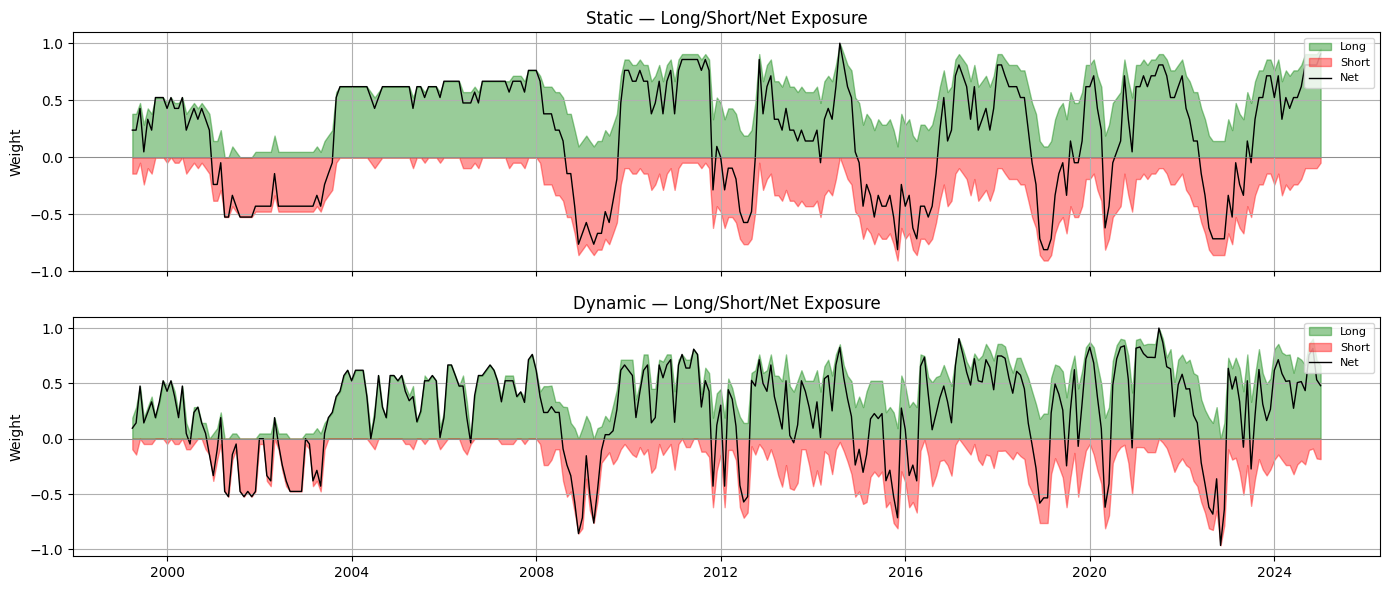

Static Gross Leverage avg: 84.8%
Dynamic Gross Leverage avg: 70.0%
Dynamic Net Exposure avg: 24.8%


In [15]:
# --- Pre-scale vs Post-scale exposure comparison ---
POST_SCALE_LEVEL = "portfolio"   # "portfolio" or "asset"
POST_SCALE_MODE  = "ex_post"     # "ex_post" or "realtime"
TARGET_VOL = 0.10
LOOKBACK = 36

# Pre-scale weights (raw 1/N × position)
eval_wt_s = wt_static.iloc[13:].dropna(how="all")
eval_wt_d = wt_dynamic.iloc[13:].dropna(how="all")
eval_idx = eval_wt_s.index

# Per-asset strategy returns (pos * r holds for BOTH static and dynamic
# because dynamic_trend_returns == pos_dynamic * returns by construction)
r_s_asset = (result["pos_static"] * returns).loc[eval_idx]
r_d_asset = (result["pos_dynamic"] * returns).loc[eval_idx]

def compute_post_scale_weights(pre_wt, r_asset):
    """Return post-scale weight DataFrame per (LEVEL, MODE) config."""
    if POST_SCALE_LEVEL == "portfolio":
        port_raw = r_asset.mean(axis=1)
        if POST_SCALE_MODE == "ex_post":
            vol = port_raw.std() * np.sqrt(12)
            scale = pd.Series(TARGET_VOL / vol, index=port_raw.index)
        else:  # realtime
            vol = port_raw.rolling(LOOKBACK).std() * np.sqrt(12)
            scale = (TARGET_VOL / vol.replace(0, np.nan)).clip(upper=3.0).shift(1)
        return pre_wt.mul(scale, axis=0)
    else:  # asset level
        if POST_SCALE_MODE == "ex_post":
            vol_per_asset = r_asset.std() * np.sqrt(12)
            scale = TARGET_VOL / vol_per_asset.replace(0, np.nan)  # Series
            return pre_wt.mul(scale, axis=1)
        else:  # realtime per-asset
            vol_per_asset = r_asset.rolling(LOOKBACK).std() * np.sqrt(12)
            scale = (TARGET_VOL / vol_per_asset.replace(0, np.nan)).clip(upper=3.0).shift(1)
            return pre_wt * scale

post_wt_s = compute_post_scale_weights(eval_wt_s, r_s_asset)
post_wt_d = compute_post_scale_weights(eval_wt_d, r_d_asset)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

def plot_exposure(ax, wt, title):
    wt = wt.dropna(how="all")
    net_long = wt.clip(lower=0).sum(axis=1)
    net_short = wt.clip(upper=0).sum(axis=1)
    ax.fill_between(wt.index, net_long, alpha=0.4, color="green", label="Long")
    ax.fill_between(wt.index, net_short, alpha=0.4, color="red", label="Short")
    ax.plot(wt.index, net_long + net_short, color="black", linewidth=1, label="Net")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel("Weight")
    ax.legend(loc="upper right", fontsize=8)

post_label = f"{POST_SCALE_LEVEL}/{POST_SCALE_MODE}"
plot_exposure(axes[0, 0], eval_wt_s, "Static — Pre-scale (directional, 1/N)")
plot_exposure(axes[0, 1], post_wt_s, f"Static — Post-scale ({post_label})")
plot_exposure(axes[1, 0], eval_wt_d, "Dynamic — Pre-scale (directional, 1/N)")
plot_exposure(axes[1, 1], post_wt_d, f"Dynamic — Post-scale ({post_label})")

plt.tight_layout()
plt.show()

print(f"=== Pre-scale ===")
print(f"Static  Gross avg: {eval_wt_s.abs().sum(axis=1).mean():.1%}   Net avg: {eval_wt_s.sum(axis=1).mean():+.1%}")
print(f"Dynamic Gross avg: {eval_wt_d.abs().sum(axis=1).mean():.1%}   Net avg: {eval_wt_d.sum(axis=1).mean():+.1%}")
print(f"\n=== Post-scale ({post_label}) ===")
print(f"Static  Gross avg: {post_wt_s.abs().sum(axis=1).mean():.1%}   Net avg: {post_wt_s.sum(axis=1).mean():+.1%}")
print(f"Dynamic Gross avg: {post_wt_d.abs().sum(axis=1).mean():.1%}   Net avg: {post_wt_d.sum(axis=1).mean():+.1%}")

In [ ]:
# --- Per-asset weight time series (user-selected tickers) ---
SELECTED_TICKERS_WT = ["SPY", "TLT", "GLD", "USO", "EWJ"]
SHOW_POST_SCALE = True  # True: post-scale notional; False: pre-scale directional

wt_source_s = post_wt_s if SHOW_POST_SCALE else eval_wt_s
wt_source_d = post_wt_d if SHOW_POST_SCALE else eval_wt_d
label_suffix = f"post-scale ({POST_SCALE_LEVEL}/{POST_SCALE_MODE})" if SHOW_POST_SCALE else "pre-scale"

tickers = [t for t in SELECTED_TICKERS_WT if t in wt_source_s.columns]
missing = [t for t in SELECTED_TICKERS_WT if t not in wt_source_s.columns]
if missing:
    print(f"[warn] tickers not in result: {missing}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
cmap = plt.cm.tab10
colors = [cmap(i % 10) for i in range(len(tickers))]

for i, col in enumerate(tickers):
    axes[0].plot(wt_source_s.index, wt_source_s[col], color=colors[i], linewidth=1.2, label=col)
    axes[1].plot(wt_source_d.index, wt_source_d[col], color=colors[i], linewidth=1.2, label=col)

for ax, title in zip(axes, [f"Static asset weight ({label_suffix})",
                             f"Dynamic asset weight ({label_suffix})"]):
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_ylabel("Weight")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9, ncol=min(len(tickers), 5))

axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Stats for selected tickers
stats_rows = []
for t in tickers:
    stats_rows.append({
        "ticker": t,
        "static_mean": wt_source_s[t].mean(),
        "static_abs_mean": wt_source_s[t].abs().mean(),
        "dynamic_mean": wt_source_d[t].mean(),
        "dynamic_abs_mean": wt_source_d[t].abs().mean(),
    })
print(f"Weight stats ({label_suffix}):")
print(pd.DataFrame(stats_rows).set_index("ticker").to_string(float_format=lambda x: f"{x:+.3f}"))